In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"E:\Courses_Udmey\Python For Machine Learning And Data Science\UNZIP_FOR_NOTEBOOKS_FINAL\08-Linear-Regression-Models\Advertising.csv")

In [3]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [4]:
X = df.drop('sales' , axis = 1)

In [5]:
y = df['sales']

In [6]:
from sklearn.preprocessing import PolynomialFeatures

In [7]:
polynomial_converter = PolynomialFeatures(degree=2 , include_bias = False)

In [8]:
polynomial_converter.fit(X)

,degree,2
,interaction_only,False
,include_bias,False
,order,'C'


In [9]:
poly_features = polynomial_converter.transform(X)

In [10]:
poly_features.shape

(200, 9)

In [11]:
X.iloc[0]

TV           230.1
radio         37.8
newspaper     69.2
Name: 0, dtype: float64

In [12]:
poly_features[0]

array([2.301000e+02, 3.780000e+01, 6.920000e+01, 5.294601e+04,
       8.697780e+03, 1.592292e+04, 1.428840e+03, 2.615760e+03,
       4.788640e+03])

In [13]:
X.head()

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [14]:
polynomial_converter.fit_transform(X)

array([[ 230.1 ,   37.8 ,   69.2 , ..., 1428.84, 2615.76, 4788.64],
       [  44.5 ,   39.3 ,   45.1 , ..., 1544.49, 1772.43, 2034.01],
       [  17.2 ,   45.9 ,   69.3 , ..., 2106.81, 3180.87, 4802.49],
       ...,
       [ 177.  ,    9.3 ,    6.4 , ...,   86.49,   59.52,   40.96],
       [ 283.6 ,   42.  ,   66.2 , ..., 1764.  , 2780.4 , 4382.44],
       [ 232.1 ,    8.6 ,    8.7 , ...,   73.96,   74.82,   75.69]],
      shape=(200, 9))

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split( poly_features, y, test_size = 0.3, random_state=101)

In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
model = LinearRegression()

In [19]:
model.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
test_predictions = model.predict(X_test)

In [21]:
# model.coef_

In [22]:
from sklearn.metrics import mean_absolute_error , mean_squared_error

In [23]:
MAE = mean_absolute_error(y_true=y_test , y_pred=test_predictions)

In [24]:
MSE = mean_squared_error(y_true=y_test , y_pred=test_predictions)

In [25]:
RMSE = np.sqrt(MSE)

In [26]:
MAE

0.4896798044803808

In [27]:
RMSE

np.float64(0.6646431757269243)

In [28]:
model.coef_

array([ 5.17095811e-02,  1.30848864e-02,  1.20000085e-02, -1.10892474e-04,
        1.14212673e-03, -5.24100082e-05,  3.34919737e-05,  1.46380310e-04,
       -3.04715806e-05])

Steps for creating multiple poly model for getting right degree

In [29]:
# create the different order poly
# split poly feat train/test
# fit on train
# store/save the rmse for BOTH the train AND test 
#PLOT the results (error vs poly order )

In [35]:
train_rmse_errors = []
test_rmse_errors =[]

for d in range(1,10):
    poly_converter = PolynomialFeatures(degree=d , include_bias = False)
    poly_features = poly_converter.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split( poly_features, y, test_size = 0.3, random_state=101)

    model = LinearRegression()
    model.fit(X_train , y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_true=y_train ,y_pred=train_pred)  )
    test_rmse = np.sqrt(mean_squared_error(y_true=y_test , y_pred=test_pred))

    train_rmse_errors.append(train_rmse)
    test_rmse_errors.append(test_rmse)
    
    
    

In [36]:
train_rmse_errors

[np.float64(1.734594124329376),
 np.float64(0.5879574085292231),
 np.float64(0.4339344356902068),
 np.float64(0.3517083688399346),
 np.float64(0.25093429446040405),
 np.float64(0.20953728966425392),
 np.float64(0.22046882092436823),
 np.float64(0.2714979031881501),
 np.float64(0.513204184935203)]

In [37]:
test_rmse_errors

[np.float64(1.516151937599388),
 np.float64(0.6646431757269243),
 np.float64(0.5803286825164237),
 np.float64(0.5077742640279537),
 np.float64(2.575825537629558),
 np.float64(9.871356038628083),
 np.float64(41.33043067765001),
 np.float64(3103.171152122394),
 np.float64(12767.682606185988)]

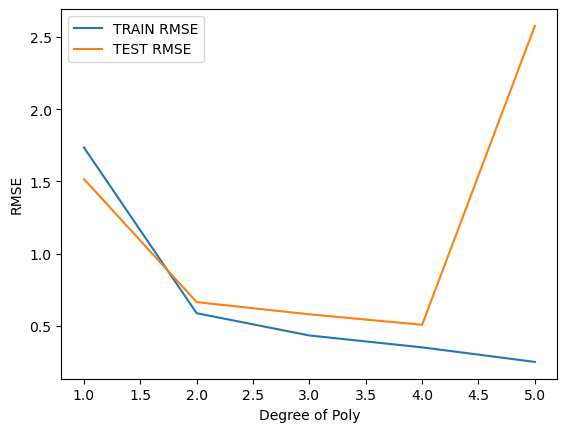

In [43]:
plt.plot(range(1,6) , train_rmse_errors[:5],label='TRAIN RMSE')
plt.plot(range(
    ,6) , test_rmse_errors[:5],label='TEST RMSE')

plt.ylabel('RMSE')
plt.xlabel('Degree of Poly')
plt.legend()

In [45]:
final_poly_converter = PolynomialFeatures(degree=3 , include_bias=False)

In [46]:
final_model = LinearRegression()

In [47]:
full_converted_X = final_poly_converter.fit_transform(X)
final_model.fit(full_converted_X , y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
from joblib import dump , load

In [49]:
dump(final_model , 'final_poly_model.joblib')

['final_poly_model.joblib']

In [50]:
dump(final_poly_converter , 'final_converter.joblib')

['final_converter.joblib']

In [53]:
loaded_converter  = load('final_converter.joblib')

In [54]:
loaded_model = load('final_poly_model.joblib')

In [72]:
campaign = [[149 ,22 ,12]]

In [73]:
tranformed_data = loaded_converter.fit_transform(campaign)

In [74]:
loaded_model.predict(tranformed_data)

array([14.64501014])

In [75]:
df['sales'].mean()

np.float64(14.0225)